# Turtle / Donchian Breakout with a De-Time Trend Filter

Classical Turtle-style breakout systems enter when price breaks above a prior high and exit on a lower-channel break. De-Time adds a trend confirmation layer so the breakout must agree with the decomposed trend.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ", "IWM", "DIA"], start="2016-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache")
features = walkforward_decompose(prices, method="STL", period=63, train_window=252, step=21)
entries, exits = turtle_donchian_signals(prices, features, entry_window=55, exit_window=20, use_trend_filter=True)
result = backtest_long_short_signals(prices, entries, exits, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,0.932556
cagr,0.065627
volatility,0.097210
sharpe,0.702664
max_drawdown,-0.147851
calmar,0.443876
hit_rate,0.307044
average_turnover,0.046899
average_gross_exposure,0.545942
fee_bps,1.000000


In [3]:
pd.DataFrame({
    "entries_per_asset": entries.sum(),
    "exits_per_asset": exits.sum(),
})

,entries_per_asset,exits_per_asset
SPY,390,180
QQQ,370,185
IWM,176,212
DIA,298,180


## Visualization: Donchian breakout channels

The SPY channel plot shows how the De-Time trend filter gates classic Donchian entries and exits.

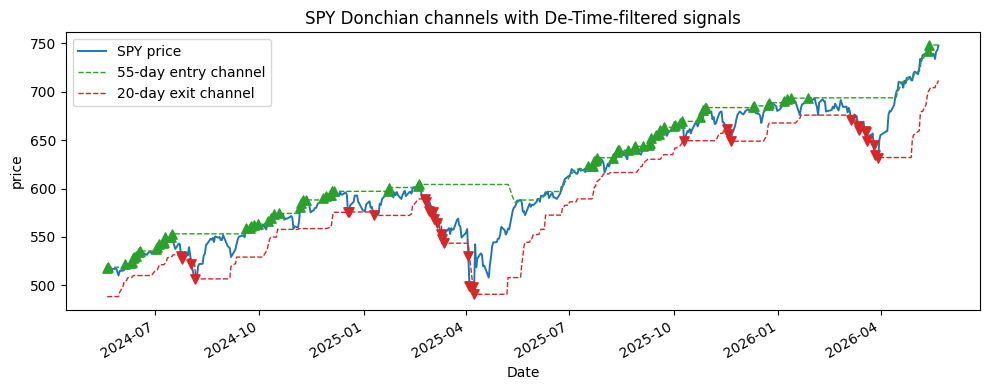

In [4]:
asset = "SPY"
window = prices.index[-504:]
price_line = prices.loc[window, asset]
upper = prices[asset].rolling(55, min_periods=27).max().shift(1).reindex(window)
lower = prices[asset].rolling(20, min_periods=10).min().shift(1).reindex(window)
entry_points = entries.loc[window, asset].fillna(False).astype(bool)
exit_points = exits.loc[window, asset].fillna(False).astype(bool)
fig, ax = plt.subplots(figsize=(10, 4))
price_line.plot(ax=ax, color="tab:blue", linewidth=1.4, label="SPY price")
upper.plot(ax=ax, color="tab:green", linestyle="--", linewidth=1.0, label="55-day entry channel")
lower.plot(ax=ax, color="tab:red", linestyle="--", linewidth=1.0, label="20-day exit channel")
ax.scatter(entry_points[entry_points].index, price_line.loc[entry_points[entry_points].index], marker="^", color="tab:green", s=45, zorder=3)
ax.scatter(exit_points[exit_points].index, price_line.loc[exit_points[exit_points].index], marker="v", color="tab:red", s=45, zorder=3)
ax.set_title("SPY Donchian channels with De-Time-filtered signals")
ax.set_ylabel("price")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


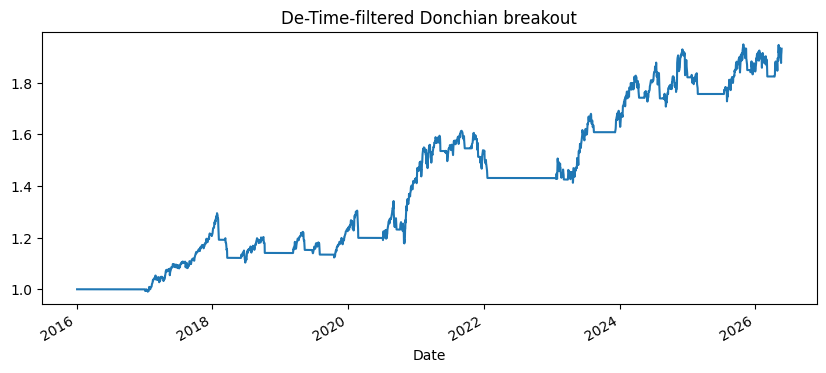

In [5]:
result.equity.plot(figsize=(10, 4), title="De-Time-filtered Donchian breakout")
plt.show()